### EXPLANATORY DATA ANALYSIS

#### Importing necessary libraries

In [30]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

In [31]:
# Pipeline Configurations
# Label map
labels = {
    0: "Normal",
    1: "Leak",
    2: "Blockage"
}

# Sensor positions
NODE_A_X = 5.0
NODE_B_X = 25.0
NODE_C_X = 45.0
tolerance = 0.5


# Feature groups
# Pressure features
pressure_features = [
    "node_a_pressure",
    "node_b_pressure",
    "node_c_pressure"
]

# Velocity features
velocity_features = [
    "velocity_a",
    "velocity_b",
    "velocity_c"
]

# Turbulent Kinetic Energy (TKE)
tke_features = [
    "tke_a",
    "tke_b",
    "tke_c"
]

# Turbulent Dissipation Rate (TDR)
tdr_features = [
    "tdr_a",
    "tdr_b",
    "tdr_c"
]

# Wall shear stress
shear_features = [
    "wall_shear_a",
    "wall_shear_b",
    "wall_shear_c"
]

# Volume of Fluid (VOF)
vof_features = [
    "tailings_vof_a",
    "tailings_vof_b",
    "tailings_vof_c"
]

# Derived features
derived_features = [
    "pressure_drop_ab",
    "pressure_drop_bc",
    "pressure_drop_ac",
    "dp_dt_a",
    "dp_dt_b",
    "dp_dt_c"
]

feature_groups = {
    "pressure": pressure_features,
    "velocity": velocity_features,
    "tke": tke_features,
    "tdr": tdr_features,
    "shear": shear_features,
    "vof": vof_features,
    "derived": derived_features
}

# Example to access the pressure group.
print(feature_groups["pressure"])

['node_a_pressure', 'node_b_pressure', 'node_c_pressure']


In [32]:
# Data Path
data_path = os.path.join(os.path.dirname(os.getcwd()), "data", "raw")
sensor_data_file_path = os.path.join(data_path, "sensor_point_dataset_raw.csv")

# Load normal dataset
#Load the dataset
df = pd.read_csv(sensor_data_file_path)
# Display the first few rows of the dataset
df.head(10)

,timestep,node_a_pressure,velocity_a,tke_a,tdr_a,wall_shear_a,tailings_vof_a,node_b_pressure,velocity_b,tke_b,...,label,effect_factor,fault_type,pressure_drop_ab,pressure_drop_bc,pressure_drop_ac,dp_dt_a,dp_dt_b,dp_dt_c,flow_velocity
0,1,37813.494210,2.493742,0.034635,24.489446,11.197253,0.409092,20025.090707,2.478308,0.036110,...,2,0.0,Blockage,17788.403503,15634.666083,33423.069587,0.000000,0.000000,0.000000,2.478308
1,2,38640.203007,2.444405,0.038275,25.658411,10.641124,0.413169,20648.853362,2.425800,0.032567,...,2,0.0,Blockage,17991.349645,16054.130065,34045.479710,1653.417594,1247.525311,408.597347,2.425800
2,3,38271.788590,2.433308,0.034279,25.294662,9.484428,0.406951,21006.247775,2.535701,0.038059,...,2,0.0,Blockage,17265.540815,17186.970665,34452.511479,-736.828834,714.788826,-1550.892373,2.535701
3,4,37714.146140,2.437858,0.032199,27.022206,9.489620,0.401694,19696.445055,2.410991,0.038042,...,2,0.0,Blockage,18017.701086,15797.893356,33815.594442,-1115.284899,-2619.605441,158.549176,2.410991
4,5,37854.377537,2.426621,0.037261,22.894842,10.660725,0.408602,19835.849879,2.446703,0.034532,...,2,0.0,Blockage,18018.527659,16795.110129,34813.637788,280.462794,278.809648,-1715.623898,2.446703
5,6,38807.292051,2.529137,0.035647,23.439768,10.250242,0.406389,19166.038199,2.526261,0.035625,...,2,0.0,Blockage,19641.253852,15446.810078,35088.063930,1905.829027,-1339.623359,1356.976745,2.526261
6,7,38164.730974,2.444688,0.034797,24.908137,10.644589,0.403550,20153.988794,2.453588,0.038813,...,2,0.0,Blockage,18010.742180,15576.550732,33587.292912,-1285.122155,1975.901189,1716.419880,2.453588
7,8,37586.003299,2.456201,0.034091,24.837599,10.843902,0.403244,19507.289644,2.487700,0.034958,...,2,0.0,Blockage,18078.713655,16248.463098,34327.176753,-1157.455349,-1293.398300,-2637.223031,2.487700
8,9,38078.566206,2.514600,0.033721,24.339944,9.959091,0.401573,20825.809266,2.437454,0.029658,...,2,0.0,Blockage,17252.756940,16978.248828,34231.005768,985.125815,2637.039245,1177.467786,2.437454
9,10,38107.607361,2.471039,0.037675,25.088742,10.973236,0.410257,19831.064198,2.484224,0.033202,...,2,0.0,Blockage,18276.543163,15445.008931,33721.552094,58.082310,-1989.490136,1076.989657,2.484224


In [33]:
#Print the shape of each
print(f"Sensor data: {df.shape}")

Sensor data: (33600, 29)


In [34]:
# Checking their datatypes
print("="*80)
print("Sensor data types")
print("="*80)
print(df.dtypes)


Sensor data types
timestep              int64
node_a_pressure     float64
velocity_a          float64
tke_a               float64
tdr_a               float64
wall_shear_a        float64
tailings_vof_a      float64
node_b_pressure     float64
velocity_b          float64
tke_b               float64
tdr_b               float64
wall_shear_b        float64
tailings_vof_b      float64
node_c_pressure     float64
velocity_c          float64
tke_c               float64
tdr_c               float64
wall_shear_c        float64
tailings_vof_c      float64
label                 int64
effect_factor       float64
fault_type              str
pressure_drop_ab    float64
pressure_drop_bc    float64
pressure_drop_ac    float64
dp_dt_a             float64
dp_dt_b             float64
dp_dt_c             float64
flow_velocity       float64
dtype: object


In [35]:
# Check for null values in the dataset
df.isnull().sum()

timestep            0
node_a_pressure     0
velocity_a          0
tke_a               0
tdr_a               0
wall_shear_a        0
tailings_vof_a      0
node_b_pressure     0
velocity_b          0
tke_b               0
tdr_b               0
wall_shear_b        0
tailings_vof_b      0
node_c_pressure     0
velocity_c          0
tke_c               0
tdr_c               0
wall_shear_c        0
tailings_vof_c      0
label               0
effect_factor       0
fault_type          0
pressure_drop_ab    0
pressure_drop_bc    0
pressure_drop_ac    0
dp_dt_a             0
dp_dt_b             0
dp_dt_c             0
flow_velocity       0
dtype: int64

In [36]:
# Check duplicated rows in the dataset
df[df.duplicated()]

,timestep,node_a_pressure,velocity_a,tke_a,tdr_a,wall_shear_a,tailings_vof_a,node_b_pressure,velocity_b,tke_b,...,label,effect_factor,fault_type,pressure_drop_ab,pressure_drop_bc,pressure_drop_ac,dp_dt_a,dp_dt_b,dp_dt_c,flow_velocity
16100,1,35642.662811,2.537158,0.034635,24.489446,11.197253,0.400409,20026.199460,2.478388,0.036109,...,1,0.0,Leak,15616.463351,15635.774786,31252.238137,0.000000,0.000000,0.000000,2.478388
16101,2,36469.371608,2.487822,0.038275,25.658411,10.641124,0.404485,20649.962116,2.425880,0.032567,...,1,0.0,Leak,15819.409493,16055.238768,31874.648261,1653.417594,1247.525311,408.597347,2.425880
16102,3,36100.957191,2.476724,0.034279,25.294662,9.484428,0.398268,21007.356529,2.535781,0.038059,...,1,0.0,Leak,15093.600662,17188.079368,32281.680030,-736.828834,714.788826,-1550.892373,2.535781
16103,4,35543.314741,2.481275,0.032199,27.022206,9.489620,0.393011,19697.553808,2.411071,0.038041,...,1,0.0,Leak,15845.760933,15799.002059,31644.762993,-1115.284899,-2619.605441,158.549176,2.411071
16104,5,35683.546139,2.470037,0.037261,22.894842,10.660725,0.399919,19836.958632,2.446783,0.034532,...,1,0.0,Leak,15846.587507,16796.218832,32642.806339,280.462794,278.809648,-1715.623898,2.446783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16795,696,36075.799419,2.475410,0.035084,22.259557,10.041336,0.397417,20084.386134,2.501823,0.036569,...,1,0.0,Leak,15991.413285,16603.160254,32594.573540,655.018653,353.316141,-992.686652,2.501823
16796,697,37088.092507,2.542123,0.035625,26.444836,9.721733,0.408165,20508.922110,2.487594,0.036272,...,1,0.0,Leak,16579.170397,16425.118073,33004.288470,2024.586175,849.071952,1205.156315,2.487594
16797,698,35962.844874,2.414947,0.037408,23.606263,10.811395,0.397146,19960.793500,2.437390,0.036623,...,1,0.0,Leak,16002.051374,14949.866214,30951.917588,-2250.495266,-1096.257221,1854.246497,2.437390
16798,699,36131.923143,2.531226,0.034066,21.414558,10.656152,0.399038,20465.573611,2.471904,0.038071,...,1,0.0,Leak,15666.349532,16418.597843,32084.947375,338.156539,1009.560223,-1927.903035,2.471904


In [37]:
# Check for unique values in the label column
print(f"Unique values in the label column: {df['label'].unique()}")

Unique values in the label column: [2 1 0]


In [38]:
# Check label distribution
label_counts = df['label'].value_counts()
print(f"Label distribution:\n{label_counts}")

Label distribution:
label
2    11200
1    11200
0    11200
Name: count, dtype: int64


In [39]:
# Get the summary statistics of the dataset
df.describe()

,timestep,node_a_pressure,velocity_a,tke_a,tdr_a,wall_shear_a,tailings_vof_a,node_b_pressure,velocity_b,tke_b,...,tailings_vof_c,label,effect_factor,pressure_drop_ab,pressure_drop_bc,pressure_drop_ac,dp_dt_a,dp_dt_b,dp_dt_c,flow_velocity
count,33600.000000,33600.000000,33600.000000,33600.000000,33600.000000,33600.000000,33600.000000,33600.000000,33600.000000,33600.000000,...,3.360000e+04,33600.000000,33600.000000,33600.000000,33600.000000,33600.000000,33600.000000,33600.000000,33600.000000,33600.000000
mean,350.500000,36534.737900,2.422621,0.036462,24.877016,11.026956,0.401527,20964.890776,2.507226,0.036976,...,3.972970e-01,1.000000,0.172917,15569.847124,17024.470770,32594.317894,1.307788,-0.491077,-1.850394,2.507226
std,202.075395,1434.713759,0.361575,0.002836,3.621901,4.395668,0.011471,3638.713997,0.203719,0.003578,...,2.619014e-02,0.816509,0.275375,3989.773845,3695.116048,1684.270283,1328.710032,1380.592278,1360.551346,0.203719
min,1.000000,34676.165823,0.000000,0.026500,16.885318,7.589720,0.364572,18660.099359,1.912035,0.026119,...,2.189194e-143,0.000000,0.000000,-7601.707294,13743.300720,29766.897583,-4413.856734,-4354.836043,-4185.872229,1.912035
25%,175.750000,35873.519895,2.424004,0.034682,23.069701,10.002692,0.396000,19765.619919,2.426563,0.034735,...,3.934105e-01,0.000000,0.000000,15484.982354,15576.533493,31616.828553,-867.105011,-949.299108,-899.946054,2.426563
50%,350.500000,36248.732880,2.474687,0.036358,24.437722,10.403456,0.400891,20161.554599,2.482002,0.036597,...,3.990629e-01,1.000000,0.000000,16088.190700,16099.137508,32172.869860,0.075770,-0.000220,-0.000022,2.482002
75%,525.250000,36629.386421,2.521236,0.038126,25.909030,10.811395,0.406832,20595.814950,2.534983,0.038754,...,4.042172e-01,2.000000,0.250000,16730.992094,16798.686108,32915.012975,884.102072,913.258463,833.983961,2.534983
max,700.000000,45000.000000,2.769596,0.045784,44.802546,40.826997,0.446441,43078.003325,3.317132,0.050000,...,5.082733e-01,2.000000,0.900000,26012.574493,39182.052449,41877.241687,4068.270519,5913.172246,4614.860421,3.317132


### Class Distrubution

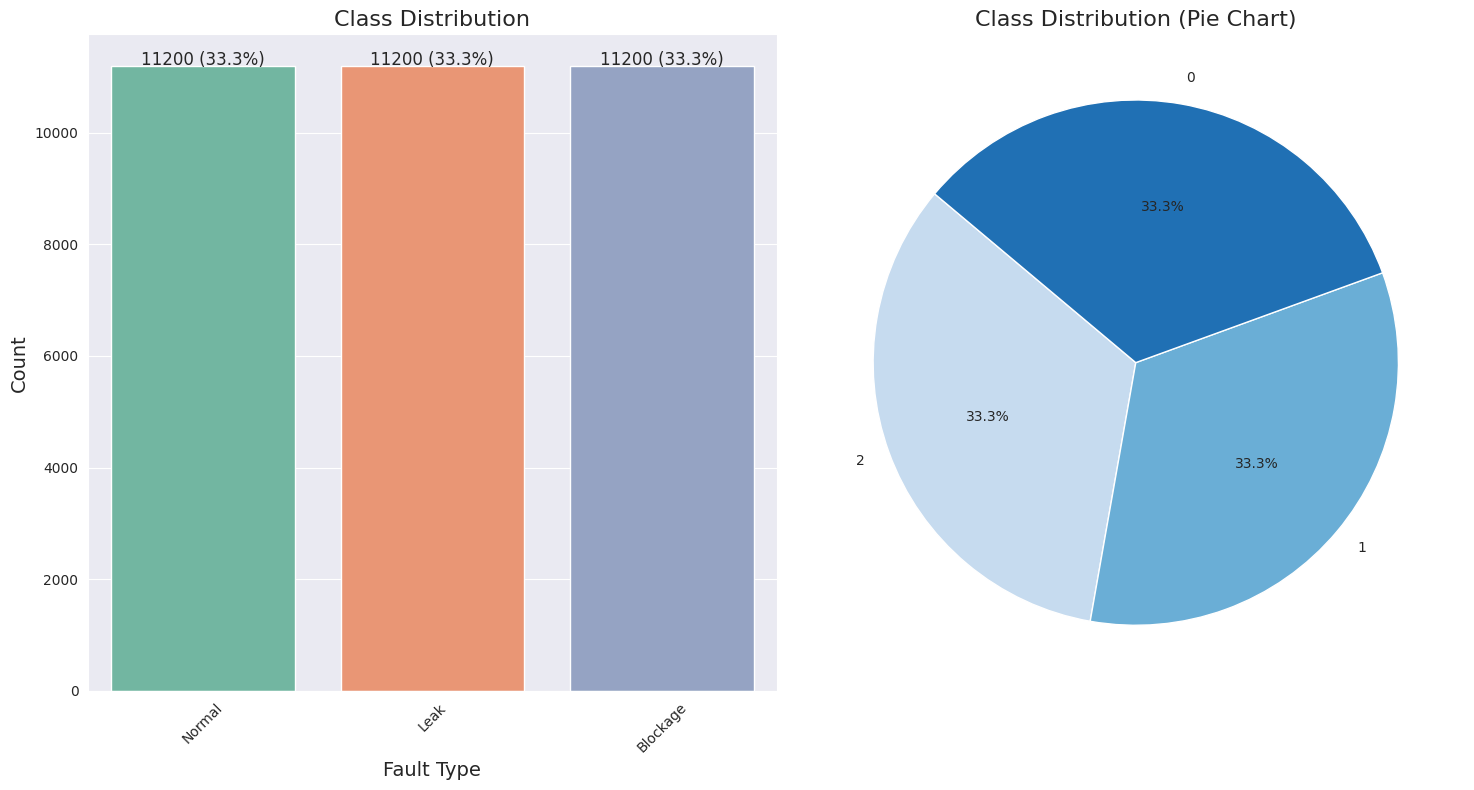

In [40]:
# Plot class distribution
fig, axes = plt.subplots(1,2, figsize=(15, 8))

# Count plot
sns.countplot(
    data= df,
    x= "fault_type",
    order = ["Normal", "Leak", "Blockage"],
    hue = "label",
    palette = 'Set2',
    ax = axes[0],
    legend = False
)

# Annotate bars
for i,(count, pct) in enumerate(zip(label_counts, label_counts/len(df)*100)):
    axes[0].text(i, count + 5, f"{count} ({pct:.1f}%)", ha='center', fontsize=12)

axes[0].set_title("Class Distribution", fontsize=16)
axes[0].set_xlabel("Fault Type", fontsize=14)
axes[0].set_ylabel("Count", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Blues", len(label_counts)))
axes[1].set_title("Class Distribution (Pie Chart)", fontsize=16)
plt.tight_layout()
plt.show()

- We have a total of 3000 samples in our dataset, with 1000 samples for each class (Normal, Leak, Blockage). This indicates a perfectly balanced dataset, which is ideal for training machine learning models as it helps prevent bias towards any particular class.
- The label distribution shows that each class (Normal, Leak, Blockage) has an equal number of samples (1000 each), confirming that the dataset is balanced. This balance is crucial for ensuring that the model learns to recognize all classes effectively without being biased towards the majority class.

### Per class statistical Summary

In [41]:
# Feature group
feature_group = ["pressure", "velocity", "tke", "tdr", "shear", "vof"]
# Compute group stats
group_stats = {}
for group_name, features in feature_groups.items():
    group_stats[group_name] = df.groupby("fault_type")[features].agg(['mean', 'std', 'min', 'max'])
# Display group stats
for group_name, stats in group_stats.items():
    print(f"\n{'='*80}\n{group_name.upper()} STATISTICS\n{'='*80}")
    print(stats)



PRESSURE STATISTICS
           node_a_pressure                                           \
                      mean          std           min           max   
fault_type                                                            
Blockage      37275.354190  2199.445553  34676.192587  45000.000000   
Leak          36149.923646   500.952366  34676.165823  37800.889011   
Normal        36178.935864   513.615821  34676.166608  38814.917600   

           node_b_pressure                                           \
                      mean          std           min           max   
fault_type                                                            
Blockage      22741.465534  5868.428073  18660.099359  43078.003325   
Leak          20102.513136   506.336482  18667.517209  21834.650359   
Normal        20050.693657   540.524005  18878.064236  21834.650359   

           node_c_pressure                                        
                      mean          std          min      